<a href="https://colab.research.google.com/github/kasrasa/ViT-VLM-experiments/blob/VLA-Experiments/VLA_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U lerobot
!pip install -q -U "lerobot[dataset,training,smolvla]"
!pip install -q -U datasets
!pip install -q "av>=15,<16"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 11.2 MB/s eta 0:00:00


In [2]:
import os
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, Subset
import torch.nn.functional as F
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights, convnext_tiny, ConvNeXt_Tiny_Weights
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from lerobot.datasets import LeRobotDataset

In [3]:
DATASET_REPO_ID = "lerobot/libero" # "lerobot/pusht" # "lerobot/svla_so101_pickplace"

dataset = LeRobotDataset(DATASET_REPO_ID)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print(torch.cuda.is_available())

print(dataset)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 457 files:   0%|          | 0/457 [00:00<?, ?it/s]

Using device: cuda
True
LeRobotDataset({
    Repository ID: 'lerobot/libero',
    Number of selected episodes: '1693',
    Number of selected samples: '273465',
    Features: '['observation.images.image', 'observation.images.image2', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})


In [4]:
sample = dataset[0]

print("Keys in one sample:")
print(sample.keys())

print("\nDetails of dataset[0]:")
for key, value in sample.items():
    print("\n" + "-" * 80)
    print("KEY:", key)
    print("TYPE:", type(value))

    if hasattr(value, "shape"):
        print("SHAPE:", value.shape)
        print("DTYPE:", getattr(value, "dtype", None))
        print("VALUE:")
        print(value)
    else:
        print("VALUE:")
        print(value)

Keys in one sample:
dict_keys(['observation.images.image', 'observation.images.image2', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])

Details of dataset[0]:

--------------------------------------------------------------------------------
KEY: observation.images.image
TYPE: <class 'torch.Tensor'>
SHAPE: torch.Size([3, 256, 256])
DTYPE: torch.float32
VALUE:
tensor([[[0.0471, 0.0471, 0.0471,  ..., 0.4549, 0.4510, 0.4510],
         [0.0471, 0.0471, 0.0471,  ..., 0.4549, 0.4510, 0.4510],
         [0.0471, 0.0471, 0.0471,  ..., 0.4510, 0.4510, 0.4510],
         ...,
         [0.3137, 0.3098, 0.3020,  ..., 0.2941, 0.2902, 0.2902],
         [0.2980, 0.2980, 0.2980,  ..., 0.3020, 0.3020, 0.3020],
         [0.2980, 0.2980, 0.2980,  ..., 0.3020, 0.3020, 0.3020]],

        [[0.0471, 0.0471, 0.0471,  ..., 0.4471, 0.4431, 0.4431],
         [0.0471, 0.0471, 0.0471,  ..., 0.4471, 0.4431, 0.4431],
         [0.0471, 0.0471, 0.0471,  ..., 0.

In [5]:
first_episode_id = int(dataset[0]["episode_index"])
print("First episode ID:", first_episode_id)

episode_indices = []

for i in range(len(dataset)):
    episode_id = int(dataset[i]["episode_index"])

    if episode_id == first_episode_id:
        episode_indices.append(i)
    elif len(episode_indices) > 0:
        break

print("Number of samples/frames in first episode:", len(episode_indices))
print("First dataset index in episode:", episode_indices[0])
print("Last dataset index in episode:", episode_indices[-1])

print("\nFirst frame_index:", dataset[episode_indices[0]]["frame_index"])
print("Last frame_index:", dataset[episode_indices[-1]]["frame_index"])

print("\nFirst timestamp:", dataset[episode_indices[0]]["timestamp"])
print("Last timestamp:", dataset[episode_indices[-1]]["timestamp"])

First episode ID: 0
Number of samples/frames in first episode: 214
First dataset index in episode: 0
Last dataset index in episode: 213

First frame_index: tensor(0)
Last frame_index: tensor(213)

First timestamp: tensor(0.)
Last timestamp: tensor(21.3000)


In [6]:
def find_keys_containing(sample, keywords):
  keys = []
  for key, value in sample.items():
    key_lower = key.lower()
    if any(word in key_lower for word in keywords):
      keys.append(key)
  return keys

image_keys = find_keys_containing(sample, ["image", "rgb", "camera"])
action_keys = find_keys_containing(sample, ["action"])
state_keys = find_keys_containing(sample, ["state", "joint", "qpos", "robot"])
language_keys = find_keys_containing(sample, ["task", "instruction", "language", "text"])
episode_keys = find_keys_containing(dataset[0], ["episode"])
frame_keys = find_keys_containing(dataset[0], ["frame", "index", "timestamp"])


print("Possible image keys:", image_keys)
print("Possible action keys:", action_keys)
print("Possible state keys:", state_keys)
print("Possible language/task keys:", language_keys)
print("Possible episode keys:", episode_keys)
print("Possible frame/time keys:", frame_keys)

Possible image keys: ['observation.images.image', 'observation.images.image2']
Possible action keys: ['action']
Possible state keys: ['observation.state']
Possible language/task keys: ['task_index', 'task']
Possible episode keys: ['episode_index']
Possible frame/time keys: ['timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


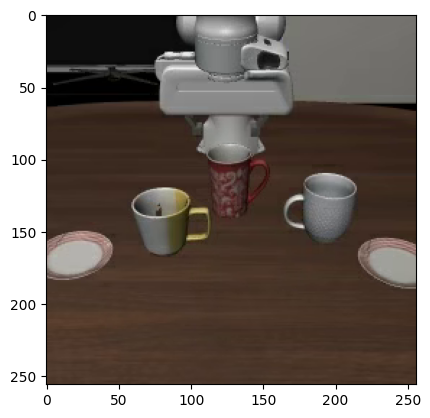

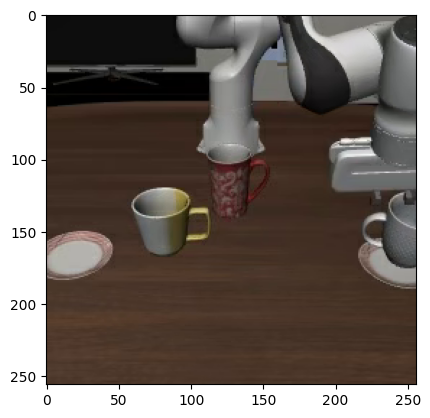

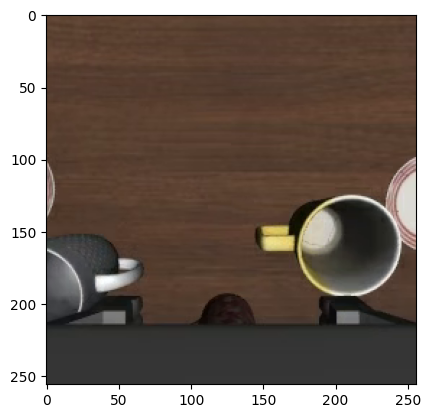

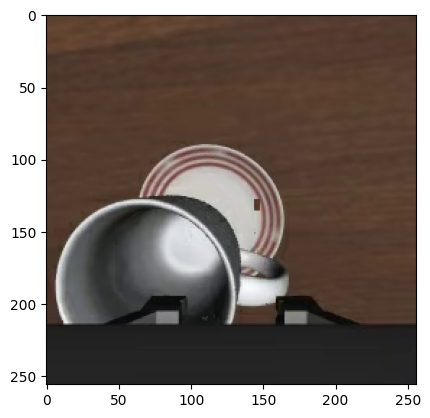

In [ ]:
def show_image_tensor(image_tensor):
  img = (image_tensor.detach().cpu().permute(1,2,0).numpy()*255).astype(np.uint8)
  plt.imshow(img)
  plt.show()

show_image_tensor(sample[image_keys[0]])
show_image_tensor(dataset[100][image_keys[0]])
show_image_tensor(sample[image_keys[1]])
show_image_tensor(dataset[100][image_keys[1]])

In [7]:
if len(action_keys) > 0:
  action_key = action_keys[0]

  actions = []

  max_samples = min(len(dataset), 5000)
  for idx in tqdm(range(max_samples), desc="Collecting actions"):
    action = dataset[idx][action_key]

    action = action.detach().cpu().numpy() if isinstance(action, torch.Tensor) else action

    action = np.asarray(action).reshape(-1)
    actions.append(action)

  actions = np.stack(actions)

  print("Actions array shape:", actions.shape)

  action_stats_df = pd.DataFrame({
      "dim": np.arange(actions.shape[1]),
      "mean": actions.mean(axis=0),
      "std": actions.std(axis=0),
      "min": actions.min(axis=0),
      "max": actions.max(axis=0),
  })

  display(action_stats_df)

Actions array shape: (5000, 7)


,dim,mean,std,min,max
0,0,0.033514,0.312053,-0.937500,0.937500
1,1,0.072047,0.354465,-0.905357,0.894643
2,2,-0.056487,0.359701,-0.894643,0.937500
3,3,0.006444,0.042002,-0.161786,0.265714
4,4,0.002826,0.060140,-0.298929,0.262500
5,5,-0.010381,0.080808,-0.348214,0.375000
6,6,-0.142400,0.989826,-1.000000,1.000000


In [8]:
if len(state_keys) > 0:
  state_key = state_keys[0]

  states = []

  max_samples = min(len(dataset), 50000)
  for idx in tqdm(range(max_samples), desc="Collecting actions"):
    state = dataset[idx][state_key]

    state = state.detach().cpu().numpy() if isinstance(state, torch.Tensor) else state

    state = np.asarray(state).reshape(-1)
    states.append(state)

  states = np.stack(states)

  print("States array shape:", states.shape)

  state_stats_df = pd.DataFrame({
      "dim": np.arange(states.shape[1]),
      "mean": states.mean(axis=0),
      "std": states.std(axis=0),
      "min": states.min(axis=0),
      "max": states.max(axis=0),
  })

  display(state_stats_df)

States array shape: (50000, 8)


,dim,mean,std,min,max
0,0,-0.043121,0.108466,-0.474147,0.210318
1,1,0.032101,0.143884,-0.325505,0.391286
2,2,0.833839,0.258553,0.445761,1.328614
3,3,2.895879,0.352986,1.132144,3.671426
4,4,-0.632719,1.236555,-3.641430,3.560651
5,5,-0.196532,0.376150,-1.842738,1.126017
6,6,0.028339,0.013324,-0.001004,0.041281
7,7,-0.028571,0.013164,-0.041117,0.000758


Using episode key: episode_index
Number of episodes inspected: 19


,episode_id,num_frames
0,0,214
1,1,284
2,2,345
3,3,285
4,4,278
5,5,240
6,6,279
7,7,272
8,8,259
9,9,302


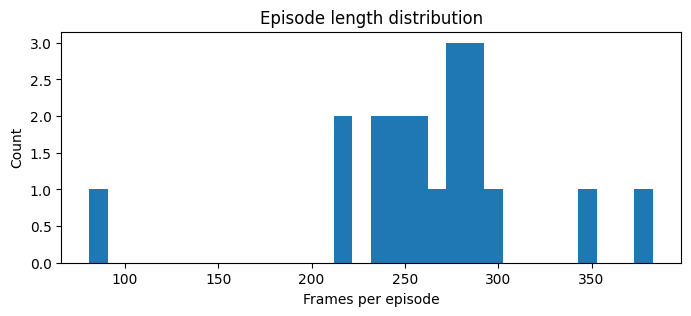

In [9]:
if len(episode_keys) > 0:
    episode_key = episode_keys[0]
    print("Using episode key:", episode_key)

    episode_ids = []

    max_samples = min(len(dataset), 5000)

    for idx in range(max_samples):
        value = dataset[idx][episode_key]

        value = int(value.item()) if isinstance(value, torch.Tensor) else int(value)

        episode_ids.append(value)

    episode_ids = np.asarray(episode_ids)

    unique_ids, count = np.unique(episode_ids, return_counts=True)

    episode_df = pd.DataFrame({
        "episode_id": unique_ids,
        "num_frames": count,
    })

    print("Number of episodes inspected:", len(episode_df))
    display(episode_df.head(20))

    plt.figure(figsize=(8, 3))
    plt.hist(episode_df["num_frames"], bins=30)
    plt.title("Episode length distribution")
    plt.xlabel("Frames per episode")
    plt.ylabel("Count")
    plt.show()
else:
    print("No episode key found.")

In [10]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def to_float_tensor(x):
    if isinstance(x, torch.Tensor):
        return x.float()
    return torch.tensor(x, dtype=torch.float32)


def get_scalar_value(x):
    if isinstance(x, torch.Tensor):
        return int(x.item())
    return int(x)

Episode 0 has 214 frames in inspected range.


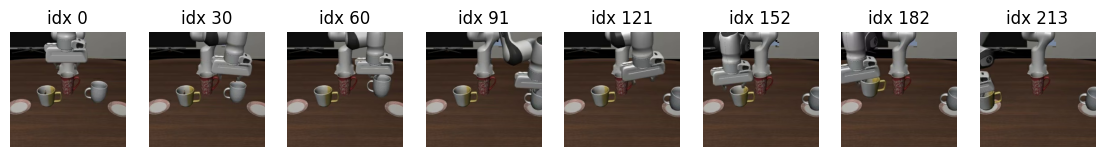

In [ ]:
if len(image_keys) > 0 and len(episode_keys) > 0:
    image_key = image_keys[0]
    episode_key = episode_keys[0]

    target_episode = get_scalar_value(dataset[0][episode_key])

    episode_indices = []
    for idx in range(min(len(dataset), 5000)):
        if get_scalar_value(dataset[idx][episode_key]) == target_episode:
            episode_indices.append(idx)

    print(f"Episode {target_episode} has {len(episode_indices)} frames in inspected range.")

    # Pick up to 8 evenly spaced frames from this episode.
    if len(episode_indices) > 0:
        chosen = np.linspace(0, len(episode_indices) - 1, min(8, len(episode_indices))).astype(int)
        chosen_indices = [episode_indices[i] for i in chosen]

        plt.figure(figsize=(14, 4))

        for plot_i, dataset_idx in enumerate(chosen_indices):
            img = dataset[dataset_idx][image_key].detach().cpu()

            if img.ndim == 3 and img.shape[0] in [1, 3, 4]:
                img = img.permute(1, 2, 0)

            img = img.numpy()
            if img.dtype != np.uint8:
                img = np.clip(img, 0, 1)

            plt.subplot(1, len(chosen_indices), plot_i + 1)
            plt.imshow(img)
            plt.title(f"idx {dataset_idx}")
            plt.axis("off")

        plt.show()
else:
    print("Need both image key and episode key to visualize a trajectory.")

In [ ]:
if len(language_keys) == 0:
    print("No language/task key found.")
else:
    for key in language_keys:
        print("\nKey:", key)
        values = []

        for idx in range(min(len(dataset), 20)):
            value = dataset[idx][key]
            values.append(value)

        for i, value in enumerate(values[:10]):
            print(f"{i}: {value}")


Key: task_index
0: 0
1: 0
2: 0
3: 0
4: 0
5: 0
6: 0
7: 0
8: 0
9: 0

Key: task
0: put the white mug on the left plate and put the yellow and white mug on the right plate
1: put the white mug on the left plate and put the yellow and white mug on the right plate
2: put the white mug on the left plate and put the yellow and white mug on the right plate
3: put the white mug on the left plate and put the yellow and white mug on the right plate
4: put the white mug on the left plate and put the yellow and white mug on the right plate
5: put the white mug on the left plate and put the yellow and white mug on the right plate
6: put the white mug on the left plate and put the yellow and white mug on the right plate
7: put the white mug on the left plate and put the yellow and white mug on the right plate
8: put the white mug on the left plate and put the yellow and white mug on the right plate
9: put the white mug on the left plate and put the yellow and white mug on the right plate


In [ ]:
def split_dataset(dataset, episode_keys, train_split = 0.8, seed = 42):
  episode_key = episode_keys[0]
  num_episodes = dataset.num_episodes
  episode_indices = np.arange(num_episodes)

  np.random.seed(seed)
  np.random.shuffle(episode_indices)

  train_size = int(train_split * num_episodes)
  train_episode_indices = episode_indices[:train_size]
  val_episode_indices = episode_indices[train_size:]

  train_indices = []
  val_indices = []

  for idx in tqdm(range(len(dataset)), desc = "collecting dataset indices"):
    episode_id = dataset[idx][episode_key]
    if episode_id in train_episode_indices:
      train_indices.append(idx)
    elif episode_id in val_episode_indices:
      val_indices.append(idx)

  return train_episode_indices, val_episode_indices, train_indices, val_indices

train_episode_indices, val_episode_indices, train_indices, val_indices = split_dataset(dataset, episode_keys)
print("Number of training episodes:", len(train_episode_indices))
print("Number of validation episodes:", len(val_episode_indices))
print("sample train episodes: ", train_episode_indices[:5])
print("sample val episodes: ", val_episode_indices[:5])
print("Number of training samples:", len(train_indices))
print("Number of validation samples:", len(val_indices))
print("sample train indices: ", np.random.randint(0,len(train_indices[:5]),10))
print("sample val indices: ", np.random.randint(0,len(val_indices[:5]),10))

collecting dataset indices:   0%|          | 0/273465 [00:00<?, ?it/s]

Number of training episodes: 1354
Number of validation episodes: 339
sample train episodes:  [1263 1685 1556 1176 1374]
sample val episodes:  [1613  959 1589  283  797]
Number of training samples: 220948
Number of validation samples: 52517
sample train indices:  [3 2 2 2 0 3 3 4 4 4]
sample val indices:  [2 3 2 0 4 2 2 0 1 3]


In [11]:
import numpy as np
import pandas as pd

def split_dataset_by_task(dataset, episode_key, task_keys, train_split=0.8, seed=42):
  rng = np.random.default_rng(seed)
  task_key = task_keys[0] # task_keys[0] == "task_index"

  episode_ids = np.asarray(dataset.hf_dataset[episode_key])

  task_ids = np.asarray(dataset.hf_dataset[task_key])

  episode_task = (
      pd.DataFrame({
          "episode": episode_ids,
          "task": task_ids,
      })
      .drop_duplicates()
  )

  train_episodes = []
  val_episodes = []

  # Split episodes separately within each task
  for task, group in episode_task.groupby("task"):
    episodes = group["episode"].to_numpy()
    rng.shuffle(episodes)

    n_train = int(len(episodes) * train_split)

    train_episodes.extend(episodes[:n_train])
    val_episodes.extend(episodes[n_train:])

  train_episodes = np.asarray(train_episodes)
  val_episodes = np.asarray(val_episodes)

  train_indices = np.where(
      np.isin(
          episode_ids,
          train_episodes
      )
  )[0]

  val_indices = np.where(
      np.isin(
          episode_ids,
          val_episodes
      )
  )[0]

  return (
      train_episodes,
      val_episodes,
      train_indices,
      val_indices,
  )

train_episode_indices, val_episode_indices, train_indices, val_indices = split_dataset_by_task(dataset, episode_keys[0], language_keys)
print("Number of training episodes:", len(train_episode_indices))
print("Number of validation episodes:", len(val_episode_indices))
print("sample train episodes: ", train_episode_indices[:5])
print("sample val episodes: ", val_episode_indices[:5])
print("Number of training samples:", len(train_indices))
print("Number of validation samples:", len(val_indices))
print("sample train indices: ", np.random.randint(0,len(train_indices[:5]),10))
print("sample val indices: ", np.random.randint(0,len(val_indices[:5]),10))

Number of training episodes: 1340
Number of validation episodes: 353
sample train episodes:  [267 236 301  85  58]
sample val episodes:  [125 167 362  22 323]
Number of training samples: 216467
Number of validation samples: 56998
sample train indices:  [0 3 3 3 3 3 0 4 1 2]
sample val indices:  [2 0 0 4 2 2 2 4 1 0]


In [12]:
def collect_actions(dataset, indices, action_key):
  actions = []
  for ind in tqdm(indices, desc="Collecting actions"):
    action = to_numpy(dataset[ind][action_key]).reshape(-1).astype(np.float32)
    actions.append(action)

  return np.stack(actions)

train_actions = collect_actions(dataset, train_indices, action_keys[0])
val_actions = collect_actions(dataset, val_indices, action_keys[0])

print("train actions shape: ", train_actions.shape)
print("val actions shape: ", val_actions.shape)

train actions shape:  (216467, 7)
val actions shape:  (56998, 7)


In [ ]:
def collect_states(dataset, indices, state_key):
  states = []
  for ind in tqdm(indices, desc="Collecting states"):
    state = to_numpy(dataset[ind][state_key]).reshape(-1).astype(np.float32)
    states.append(state)

  return np.stack(states)

train_states = collect_states(dataset, train_indices, state_keys[0])
val_states = collect_states(dataset, val_indices, state_keys[0])

print("train states shape: ", train_states.shape)
print("val states shape: ", val_states.shape)

In [ ]:
def best_row(history_df, metric="val_mae"):
    return history_df.loc[history_df[metric].idxmin()]


def per_action_dim_metrics(y_true, y_pred):
  y_true = np.asarray(y_true)
  y_pred = np.asarray(y_pred)

  error = y_pred - y_true

  mae = np.mean(np.abs(error), axis=0)
  mse = np.mean(error**2, axis=0)

  true_std = np.std(y_true, axis=0)

  relative_mae = mae / (true_std + 1e-8)

  rows = []
  for dim in range(y_true.shape[1]):
        rows.append({
            "action_dim": dim,
            "mae": mae[dim],
            "relative_mae": relative_mae[dim]
        })

  return pd.DataFrame(rows)


def plot_action_trajectory(y_true, y_pred, num_steps=300):
    n = min(num_steps, len(y_true))

    for dim in range(y_true.shape[1]):
        plt.figure(figsize=(10, 3))

        plt.plot(
            np.arange(n),
            y_true[:n, dim],
            label="Expert action"
        )

        plt.plot(
            np.arange(n),
            y_pred[:n, dim],
            label="Predicted action"
        )

        plt.xlabel("Time step")
        plt.ylabel(f"Action dimension {dim}")
        plt.title(f"Action dimension {dim}")
        plt.legend()
        plt.grid(True)
        plt.show()

# Mean Action Prediciton

In [ ]:
def mean_action_predictor(dataset, val_indices, action_key, train_actions):
  y_true = collect_actions(dataset, val_indices, action_key)

  train_action_mean = train_actions.mean(axis=0)
  y_pred = np.full_like(y_true, train_action_mean)

  mae = np.mean(np.abs(y_true - y_pred))
  mse = np.mean((y_true - y_pred)**2)

  pre_dim_metrics = per_action_dim_metrics(y_true, y_pred)

  plot_action_trajectory(y_true, y_pred)

  return {
      "mae": mae,
      "mse": mse,
      "per_dim_metrics": pre_dim_metrics
  }


mean_baseline = mean_action_predictor(dataset, val_indices, action_keys[0], train_actions)
print("mae: ", mean_baseline["mae"])
print("mse: ", mean_baseline["mse"])

display(mean_baseline["per_dim_metrics"])

KeyboardInterrupt: 

# Previous Action Prediction

In [ ]:
def _same_episode(idx, episode_key):
  if idx == 0:
    return False

  current_sample = dataset[idx][episode_key]
  previous_sample = dataset[idx-1][episode_key]

  if isinstance(current_sample, torch.Tensor):
      current_sample = int(current_sample.item())
  else:
      current_sample = int(current_sample)

  if isinstance(previous_sample, torch.Tensor):
      previous_sample = int(previous_sample.item())
  else:
      previous_sample = int(previous_sample)

  return current_sample == previous_sample

def previous_action_prediction(dataset, val_indices, action_key, episode_key):
  y_pred = []
  y_true = []

  for ind in tqdm(val_indices, desc="Collecting actions"):
    if ind - 1 not in val_indices:
          continue

    if not _same_episode(ind, episode_key):
      continue

    y_true.append(to_numpy(dataset[ind][action_key]).reshape(-1).astype(np.float32))
    y_pred.append(to_numpy(dataset[ind-1][action_key]).reshape(-1).astype(np.float32))


  y_true = np.stack(y_true)
  y_pred = np.stack(y_pred)

  mae = np.mean(np.abs(y_true - y_pred))
  mse = np.mean((y_true - y_pred)**2)

  per_dim_metrics = per_action_dim_metrics(y_true, y_pred)

  plot_action_trajectory(y_true, y_pred)

  return {
      "mae": mae,
      "mse": mse,
      "per_dim_metrics": per_dim_metrics,
  }


prev_baseline = previous_action_prediction(dataset, val_indices, action_keys[0], episode_keys[0])
print("mae: ", prev_baseline["mae"])
print("mse: ", prev_baseline["mse"])

display(prev_baseline["per_dim_metrics"])

# State Action Predition

In [ ]:
class StateActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, train_actions, train_states):
    self.dataset = dataset
    self.indices = indices
    self.state_key = state_key
    self.action_key = action_key
    self.train_actions = torch.as_tensor(train_actions, dtype=torch.float32)
    self.train_states = torch.as_tensor(train_states, dtype=torch.float32)

    self.train_action_mean = self.train_actions.mean(dim=0)
    self.train_action_std = self.train_actions.std(dim=0, correction=0) + 1e-6

    self.train_state_mean = self.train_states.mean(dim=0)
    self.train_state_std = self.train_states.std(dim=0, correction=0) + 1e-6

    states = []
    actions = []

    for idx in self.indices:
      state = to_float_tensor(self.dataset[idx][state_key]).reshape(-1)
      action = to_float_tensor(self.dataset[idx][action_key]).reshape(-1)

      states.append(state)
      actions.append(action)

    self.states = torch.stack(states)
    self.actions = torch.stack(actions)

    self.states_norm = (self.states - self.train_state_mean) / self.train_state_std
    self.actions_norm = (self.actions - self.train_action_mean) / self.train_action_std


  def __len__(self):
    return len(self.indices)

  def __getitem__(self, i):
    return {
        "state": self.states[i],
        "action": self.actions[i],
        "state_norm": self.states_norm[i],
        "action_norm": self.actions_norm[i],
        "dataset_index": self.indices[i]
    }

In [ ]:
class MLP_head(torch.nn.Module):
  def __init__(self, state_dim, action_dim, hidden_dim=256):
    super().__init__()
    self.mlp = torch.nn.Sequential(
        torch.nn.Linear(state_dim, hidden_dim),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_dim, hidden_dim),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_dim, action_dim)
    )

  def forward(self, state):
    return self.mlp(state)

In [ ]:
def train_one_epoch(model, optimizer, train_dataloader, device):
  model.train()
  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    state_norm, action_norm = batch["state_norm"].to(device), batch["action_norm"].to(device)

    action_pred = model(state_norm)
    loss = F.mse_loss(action_pred, action_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_size = state_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    if step%100 == 0:
      print("running loss at step", step, ":", running_loss / max(total_count, 1))

  return running_loss / max(total_count, 1)


@torch.no_grad()
def evaluate_model(model, val_dataloader, action_mean, action_std, device):
  model.eval()

  action_mean = action_mean.to(device)
  action_std = action_std.to(device)

  all_true = []
  all_pred = []

  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
    state_norm, action_norm = batch["state_norm"].to(device), batch["action_norm"].to(device)
    action = batch["action"].to(device)

    action_pred_norm = model(state_norm)
    loss = F.mse_loss(action_pred_norm, action_norm)

    batch_size = state_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    unnorm_action_pred = action_pred_norm * action_std + action_mean
    all_true.append(action.cpu().numpy())
    all_pred.append(unnorm_action_pred.cpu().numpy())

  all_true = np.concatenate(all_true, axis=0)
  all_pred = np.concatenate(all_pred, axis=0)

  mae = np.mean(np.abs(all_true - all_pred))
  mse = np.mean((all_true - all_pred)**2)

  per_dim_metrics = per_action_dim_metrics(all_true, all_pred)

  return {
        "loss": running_loss / max(total_count, 1),
        "mae": mae,
        "mse": mse,
        "per_dim_metrics": per_dim_metrics,
        "y_true": all_true,
        "y_pred": all_pred,
    }

In [ ]:
train_state_ds = StateActionDataset(
    dataset,
    train_indices,
    state_key,
    action_key,
    train_actions,
    train_states,
)

val_state_ds = StateActionDataset(
    dataset,
    val_indices,
    state_key,
    action_key,
    train_actions,
    train_states,
)

sample_batch = train_state_ds[0]
state_dim = sample_batch["state_norm"].numel()
action_dim = sample_batch["action_norm"].numel()

print("State dim:", state_dim)
print("Action dim:", action_dim)

state_train_dataloader = DataLoader(
    train_state_ds,
    batch_size=64,
    shuffle=True,
)

state_val_dataloader = DataLoader(
    val_state_ds,
    batch_size=64,
    shuffle=False,
)

state_model = MLP_head(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=512,
).to(device)

optimizer = torch.optim.AdamW(
    state_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = []

NUM_EPOCHS = 1

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        state_model,
        optimizer,
        state_train_dataloader,
        device,
    )

    val_metrics = evaluate_model(
        state_model,
        state_val_dataloader,
        train_state_ds.train_action_mean,
        train_state_ds.train_action_std,
        device,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
    }

    history.append(row)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mae={val_metrics['mae']:.4f} | "
        f"val_mse={val_metrics['mse']:.4f}"
    )

per_dim_val_metrics = evaluate_model(
    state_model,
    state_val_dataloader,
    train_state_ds.train_action_mean,
    train_state_ds.train_action_std,
    device
)

display(per_dim_val_metrics["per_dim_metrics"])
plot_action_trajectory(per_dim_val_metrics["y_true"], per_dim_val_metrics["y_pred"])

state_history_df = pd.DataFrame(history)
display(state_history_df)

# State + Previous Action Prediction

In [ ]:
class StatePrevActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states):
    self.dataset = dataset
    self.indices = indices
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = torch.as_tensor(train_actions, dtype=torch.float32)
    self.train_states = torch.as_tensor(train_states, dtype=torch.float32)

    self.train_action_mean = self.train_actions.mean(dim=0)
    self.train_action_std = self.train_actions.std(dim=0, correction=0) + 1e-6

    self.train_state_mean = self.train_states.mean(dim=0)
    self.train_state_std = self.train_states.std(dim=0, correction=0) + 1e-6

    states = []
    actions = []
    previous_actions = []
    has_previous_actions = []

    for idx in self.indices:
      state = to_float_tensor(self.dataset[idx][state_key]).reshape(-1)
      action = to_float_tensor(self.dataset[idx][action_key]).reshape(-1)

      if self._same_episode(idx):
        previous_action = to_float_tensor(self.dataset[idx-1][self.action_key]).reshape(-1)
        has_previous_action = torch.tensor([1.0])
      else:
        previous_action = torch.zeros_like(action)
        has_previous_action = torch.tensor([0.0])

      states.append(state)
      actions.append(action)
      previous_actions.append(previous_action)
      has_previous_actions.append(has_previous_action)

    self.states = torch.stack(states)
    self.actions = torch.stack(actions)
    self.previous_actions = torch.stack(previous_actions)
    self.has_previous_actions = torch.stack(has_previous_actions)

    self.states_norm = (self.states - self.train_state_mean) / self.train_state_std
    self.actions_norm = (self.actions - self.train_action_mean) / self.train_action_std
    self.previous_actions_norm = (self.previous_actions - self.train_action_mean) / self.train_action_std
    self.previous_actions_norm = (self.previous_actions_norm * self.has_previous_actions)

    self.input_bundle = torch.cat([self.states, self.previous_actions, self.has_previous_actions], dim=1)
    self.input_norm_bundle = torch.cat([self.states_norm, self.previous_actions_norm, self.has_previous_actions], dim=1)

  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx == 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample = self.dataset[idx-1][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample, torch.Tensor):
        previous_sample = int(previous_sample.item())
    else:
        previous_sample = int(previous_sample)

    return current_sample == previous_sample

  def __getitem__(self, i):
    return {
        "state": self.input_bundle[i],
        "action": self.actions[i],
        "action_norm": self.actions_norm[i],
        "state_norm": self.input_norm_bundle[i],
        "dataset_index": self.indices[i]
    }

In [ ]:
train_prevaction_ds = StatePrevActionDataset(
    dataset,
    train_indices,
    state_key,
    action_key,
    episode_key,
    train_actions,
    train_states,
)

val_prevaction_ds = StatePrevActionDataset(
    dataset,
    val_indices,
    state_key,
    action_key,
    episode_key,
    train_actions,
    train_states,
)

sample_batch = train_prevaction_ds[0]
state_dim = sample_batch["state_norm"].numel()
action_dim = sample_batch["action_norm"].numel()

print("State dim:", state_dim)
print("Action dim:", action_dim)

prevaction_train_dataloader = DataLoader(
    train_prevaction_ds,
    batch_size=64,
    shuffle=True,
)

prevaction_val_dataloader = DataLoader(
    val_prevaction_ds,
    batch_size=64,
    shuffle=False,
)

prevaction_model = MLP_head(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=512,
).to(device)

optimizer = torch.optim.AdamW(
    prevaction_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = []

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        prevaction_model,
        optimizer,
        prevaction_train_dataloader,
        device,
    )

    val_metrics = evaluate_model(
        prevaction_model,
        prevaction_val_dataloader,
        train_prevaction_ds.train_action_mean,
        train_prevaction_ds.train_action_std,
        device,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
    }

    history.append(row)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mae={val_metrics['mae']:.4f} | "
        f"val_mse={val_metrics['mse']:.4f}"
    )

final_per_dim_val_metrics = evaluate_model(
    prevaction_model,
    prevaction_val_dataloader,
    train_prevaction_ds.train_action_mean,
    train_prevaction_ds.train_action_std,
    device
)

display(final_per_dim_val_metrics["per_dim_metrics"])
plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

prevaction_history_df = pd.DataFrame(history)
display(prevaction_history_df)

# State + k Previous Action Prediction

In [ ]:
class StatePrevKActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states, k=2):
    self.dataset = dataset
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = torch.as_tensor(train_actions, dtype=torch.float32)
    self.train_states = torch.as_tensor(train_states, dtype=torch.float32)
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = self.train_actions.mean(axis=0)
    self.train_action_std = self.train_actions.std(axis=0, correction=0) + 1e-6

    self.train_state_mean = self.train_states.mean(axis=0)
    self.train_state_std = self.train_states.std(axis=0, correction=0) + 1e-6

    previous_actions_k = []
    previous_states_k = []
    states = []
    actions = []

    for idx in self.indices:
      state = to_float_tensor(self.dataset[idx][self.state_key]).reshape(-1)
      action = to_float_tensor(self.dataset[idx][self.action_key]).reshape(-1)

      sample_previous_actions = []
      sample_previous_states = []
      for offset in range(1, self.k+1):
        previous_action_k = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
        previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)

        sample_previous_actions.append(previous_action_k)
        sample_previous_states.append(previous_state_k)

      sample_previous_actions = torch.stack(sample_previous_actions)
      sample_previous_states = torch.stack(sample_previous_states)

      states.append(state)
      actions.append(action)

      previous_actions_k.append(sample_previous_actions)
      previous_states_k.append(sample_previous_states)

    self.states = torch.stack(states)
    self.actions = torch.stack(actions)
    self.previous_actions_k = torch.stack(previous_actions_k)
    self.previous_states_k = torch.stack(previous_states_k)

    self.states_norm = (self.states - self.train_state_mean) / self.train_state_std
    self.actions_norm = (self.actions - self.train_action_mean) / self.train_action_std
    self.previous_actions_k_norm = (self.previous_actions_k - self.train_action_mean) / self.train_action_std
    self.previous_states_k_norm = (self.previous_states_k - self.train_state_mean) / self.train_state_std

    previous_states_flat = self.previous_states_k.flatten(start_dim=1)
    previous_actions_flat = (self.previous_actions_k.flatten(start_dim=1))
    previous_states_norm_flat = (self.previous_states_k_norm.flatten(start_dim=1))
    previous_actions_norm_flat = (self.previous_actions_k_norm.flatten(start_dim=1))

    self.input_bundle = torch.cat([self.states, previous_states_flat, previous_actions_flat], dim=1)
    self.input_norm_bundle = torch.cat([self.states_norm, previous_states_norm_flat, previous_actions_norm_flat], dim=1)

  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    return {
        "state": self.input_bundle[i],
        "action": self.actions[i],
        "action_norm": self.actions_norm[i],
        "state_norm": self.input_norm_bundle[i],
        "dataset_index": self.indices[i]
    }

In [ ]:
K = [2,4,8]
prevk_histories_df = {}

for k in K:
  train_prevk_ds = StatePrevKActionDataset(
      dataset,
      train_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  val_prevk_ds = StatePrevKActionDataset(
      dataset,
      val_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  sample_batch = train_prevk_ds[0]
  state_dim = sample_batch["state_norm"].numel()
  action_dim = sample_batch["action_norm"].numel()

  print("State dim:", state_dim)
  print("Action dim:", action_dim)

  prevk_train_dataloader = DataLoader(
      train_prevk_ds,
      batch_size=64,
      shuffle=True,
  )

  prevk_val_dataloader = DataLoader(
      val_prevk_ds,
      batch_size=64,
      shuffle=False,
  )

  prevk_model = MLP_head(
      state_dim=state_dim,
      action_dim=action_dim,
      hidden_dim=512,
  ).to(device)

  optimizer = torch.optim.AdamW(
      prevk_model.parameters(),
      lr=1e-3,
      weight_decay=1e-4,
  )

  history = []

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch(
          prevk_model,
          optimizer,
          prevk_train_dataloader,
          device,
      )

      val_metrics = evaluate_model(
          prevk_model,
          prevk_val_dataloader,
          train_prevk_ds.train_action_mean,
          train_prevk_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f} | "
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_per_dim_val_metrics = evaluate_model(
      prevk_model,
      prevk_val_dataloader,
      train_prevk_ds.train_action_mean,
      train_prevk_ds.train_action_std,
      device
  )

  display(final_per_dim_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

  prevk_histories_df[k] = pd.DataFrame(history)
  display(prevk_histories_df[k])

# GRU Policy

In [ ]:
class GRUDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states, k=2):
    self.dataset = dataset
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = torch.as_tensor(train_actions, dtype=torch.float32)
    self.train_states = torch.as_tensor(train_states, dtype=torch.float32)
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = self.train_actions.mean(axis=0)
    self.train_action_std = self.train_actions.std(axis=0, correction=0) + 1e-6

    self.train_state_mean = self.train_states.mean(axis=0)
    self.train_state_std = self.train_states.std(axis=0, correction=0) + 1e-6

    actions = []
    actions_norm = []
    sequences = []

    for idx in self.indices:
      action = to_float_tensor(self.dataset[idx][self.action_key]).reshape(-1)
      state = to_float_tensor(self.dataset[idx][self.state_key]).reshape(-1)

      action_norm = (action - self.train_action_mean) / self.train_action_std
      state_norm = (state - self.train_state_mean) / self.train_state_std

      current_token = torch.cat([state_norm, torch.zeros_like(action_norm), torch.tensor([0.0])], dim=0)

      sequence = []

      # -------------------------------------
      # Historical tokens
      #
      # [state_(t-k), action_(t-k), 1]
      # ...
      # [state_(t-1), action_(t-1), 1]
      # -------------------------------------
      for offset in range(self.k, 0, -1):
        previous_action_k  = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
        previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)

        previous_action_k_norm = (previous_action_k - self.train_action_mean) / self.train_action_std
        previous_state_k_norm = (previous_state_k - self.train_state_mean) / self.train_state_std

        token = torch.cat([previous_state_k_norm, previous_action_k_norm, torch.tensor([1.0])], dim=0)

        sequence.append(token)

      sequence.append(current_token)
      sequence = torch.stack(sequence, dim=0)

      actions.append(action)
      actions_norm.append(action_norm)
      sequences.append(sequence)

    self.sequences = torch.stack(sequences)
    self.actions = torch.stack(actions)
    self.actions_norm = torch.stack(actions_norm)

  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    return {
        "action": self.actions[i],
        "action_norm": self.actions_norm[i],
        "state_norm": self.sequences[i],
        "dataset_index": self.indices[i]
    }

In [ ]:
class GRUActionPolicy(nn.Module):
    def __init__(
        self,
        input_dim,
        action_dim,
        hidden_dim=256,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.action_head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, sequence_norm):
        output, hidden = self.gru(sequence_norm)
        last_hidden = output[:, -1, :]
        action_norm = self.action_head(last_hidden)
        return action_norm

In [ ]:
K = [2,4,8]
gru_histories_df = {}

for k in K:
  train_gru_ds = GRUDataset(
      dataset,
      train_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  val_gru_ds = GRUDataset(
      dataset,
      val_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  sample_batch = train_gru_ds[0]
  state_dim = sample_batch["state_norm"].shape[1]
  action_dim = sample_batch["action_norm"].numel()

  print("State dim:", state_dim)
  print("Action dim:", action_dim)

  gru_train_dataloader = DataLoader(
      train_gru_ds,
      batch_size=64,
      shuffle=True,
  )

  gru_val_dataloader = DataLoader(
      val_gru_ds,
      batch_size=64,
      shuffle=False,
  )

  gru_model = GRUActionPolicy(
    input_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=512,
    num_layers=3,
    dropout=0.2,
  ).to(device)

  optimizer = torch.optim.AdamW(
      gru_model.parameters(),
      lr=1e-3,
      weight_decay=1e-4,
  )

  sample_batch = next(iter(gru_train_dataloader))
  x = sample_batch["state_norm"].to(device)

  with torch.no_grad():
      pred = gru_model(x)

  print("input:", x.shape)
  print("prediction:", pred.shape)

  history = []

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch(
          gru_model,
          optimizer,
          gru_train_dataloader,
          device,
      )

      val_metrics = evaluate_model(
          gru_model,
          gru_val_dataloader,
          train_gru_ds.train_action_mean,
          train_gru_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f} | "
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_per_dim_val_metrics = evaluate_model(
    gru_model,
    gru_val_dataloader,
    train_gru_ds.train_action_mean,
    train_gru_ds.train_action_std,
    device
    )

  display(final_per_dim_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

  gru_histories_df[k] = pd.DataFrame(history)
  display(gru_histories_df[k])

# Image State Previous K Action Prediction

In [ ]:
class ImagekPrevActionDataset(Dataset):
  def __init__(self, dataset, indices, image_keys, state_key, action_key, episode_key, train_actions, train_states, k):
    self.dataset = dataset
    self.image_keys = image_keys
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = torch.as_tensor(train_actions, dtype=torch.float32)
    self.train_states = torch.as_tensor(train_states, dtype=torch.float32)
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = self.train_actions.mean(axis=0)
    self.train_action_std = self.train_actions.std(axis=0, correction=0) + 1e-6

    self.train_state_mean = self.train_states.mean(axis=0)
    self.train_state_std = self.train_states.std(axis=0, correction=0) + 1e-6

    actions = []
    actions_norm = []
    sequences = []

    for idx in self.indices:
      action = to_float_tensor(self.dataset[idx][self.action_key]).reshape(-1)
      state = to_float_tensor(self.dataset[idx][self.state_key]).reshape(-1)

      action_norm = (action - self.train_action_mean) / self.train_action_std
      state_norm = (state - self.train_state_mean) / self.train_state_std

      current_token = torch.cat([state_norm, torch.zeros_like(action_norm), torch.tensor([0.0])], dim=0)

      sequence = []
      # -----------------------------------------
      # Historical state/action pairs
      #
      # [state_(t-k), action_(t-k), action available]
      # ...
      # [state_(t-1), action_(t-1), action available]
      # -----------------------------------------
      for offset in range(self.k, 0, -1):
        previous_action_k = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
        previous_action_k_norm = (previous_action_k - self.train_action_mean) / self.train_action_std

        previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)
        previous_state_k_norm = (previous_state_k - self.train_state_mean) / self.train_state_std

        token = torch.cat([previous_state_k_norm, previous_action_k_norm, torch.tensor([1.0])], dim=0)
        sequence.append(token)

      sequence.append(current_token)
      sequence = torch.stack(sequence, dim=0)

      actions.append(action)
      actions_norm.append(action_norm)
      sequences.append(sequence)

    self.sequences = torch.stack(sequences)
    self.actions = torch.stack(actions)
    self.actions_norm = torch.stack(actions_norm)

  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    idx = self.indices[i]

    sample_images = []

    for image_key in self.image_keys:
        image = to_float_tensor(self.dataset[idx][image_key])
        image_norm = image / 255.0 if image.max() > 2.0 else image

        sample_images.append(image_norm)

    images_norm = torch.stack(sample_images, dim=0)

    return {
        "action": self.actions[i],
        "action_norm": self.actions_norm[i],
        "state_norm": self.sequences[i],
        "images_norm": self.images[i],
        "dataset_index": self.indices[i]
    }

In [ ]:
class kActionImageEncoder(nn.Module):
  def __init__(self, backbone_name = "convnext_tiny", embedding_dim=256, freeze_backbone=True, multi_view = False):
    super().__init__()

    self.backbone_name = backbone_name
    self.freeze_backbone = freeze_backbone
    self.multi_view = multi_view
    self.embedding_dim = embedding_dim

    if backbone_name == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = resnet50(weights=weights)

        feature_dim = model.fc.in_features
        model.fc = nn.Identity()

        self.backbone = model

    elif backbone_name == "convnext_tiny":
        weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        model = convnext_tiny(weights=weights)

        feature_dim = model.classifier[-1].in_features

        self.backbone = nn.Sequential(
            model.features,
            model.avgpool,
            nn.Flatten(1),
        )

    else:
        raise ValueError(
            f"Unknown backbone: {backbone_name}. "
            "Use 'resnet50' or 'convnext_tiny'."
        )

    if self.freeze_backbone:
      for param in self.backbone.parameters():
          param.requires_grad = False

    self.head = nn.Sequential(
        nn.Linear(feature_dim, 512),
        nn.ReLU(),
        nn.Linear(512, self.embedding_dim),
        )

  def forward(self, images):
    if self.multi_view:
      B, V, C, H, W = images.shape

      images = images.reshape(B*V, C, H, W)

      if self.freeze_backbone:
        self.backbone.eval()
        with torch.no_grad():
            encoded = self.backbone(images)
      else:
        encoded = self.backbone(images)

      embeddings = self.head(encoded)

    if self.multi_view:
      embeddings = embeddings.reshape(B, V, self.embedding_dim)

    return embeddings

In [ ]:
class GRUEncoder(nn.Module):
    def __init__(
        self,
        input_dim,
        embedding_dim=256,
        hidden_dim=256,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.projection = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, sequence_norm):
        _, hidden = self.gru(sequence_norm)
        last_hidden = hidden[-1]
        embedding = self.projection(last_hidden)
        return embedding

In [ ]:
class FusionMLP(nn.Module):
  def __init__(self, input_dim, action_dim, hidden_dim=512):
    super().__init__()
    self.input_dim = input_dim
    self.action_dim = action_dim
    self.hidden_dim = hidden_dim

    self.mlp = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, action_dim),
    )

  def forward(self, input_bundle):
    return self.mlp(input_bundle)

In [ ]:
def train_one_epoch_image_kprev(image_model, gru_model, fusion_head, optimizer, train_dataloader, device):
  image_model.train()
  gru_model.train()
  fusion_head.train()
  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    images_norm = batch["images_norm"].to(device)
    state_norm = batch["state_norm"].to(device)
    action_norm = batch["action_norm"].to(device)

    image_embeddings = image_model(images_norm)
    image_embeddings = image_embeddings.flatten(start_dim=1)
    state_embedding = gru_model(state_norm)

    input_bundle = torch.cat([image_embeddings, state_embedding], dim=1)
    action_pred = fusion_head(input_bundle)
    loss = F.mse_loss(action_pred, action_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    if step%100 == 0:
      print("running loss at step", step, ":", running_loss / max(total_count, 1))

  return running_loss / max(total_count, 1)

@torch.no_grad()
def evaluate_model_image_kprev(image_model, gru_model, fusion_head, val_dataloader, action_mean, action_std, device):
  image_model.eval()
  gru_model.eval()
  fusion_head.eval()

  action_mean = action_mean.to(device)
  action_std = action_std.to(device)

  all_true = []
  all_pred = []

  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
    images_norm = batch["images_norm"].to(device)
    state_norm = batch["state_norm"].to(device)
    action_norm = batch["action_norm"].to(device)
    action = batch["action"].to(device)

    image_embeddings = image_model(images_norm)
    image_embeddings = image_embeddings.flatten(start_dim=1)
    state_embedding = gru_model(state_norm)

    input_bundle = torch.cat([image_embeddings, state_embedding], dim=1)
    action_pred_norm = fusion_head(input_bundle)
    loss = F.mse_loss(action_pred_norm, action_norm)

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    unnorm_action_pred = action_pred_norm * action_std + action_mean
    all_true.append(action.cpu().numpy())
    all_pred.append(unnorm_action_pred.cpu().numpy())

  all_true = np.concatenate(all_true, axis=0)
  all_pred = np.concatenate(all_pred, axis=0)

  mae = np.mean(np.abs(all_true - all_pred))
  mse = np.mean((all_true - all_pred)**2)

  per_dim_metrics = per_action_dim_metrics(all_true, all_pred)

  return {
        "loss": running_loss / max(total_count, 1),
        "mae": mae,
        "mse": mse,
        "per_dim_metrics": per_dim_metrics,
        "y_true": all_true,
        "y_pred": all_pred
  }

In [ ]:
K = [2,4,8]
image_kprev_action_histories_df = {}
BACKBONE_NAME = "resnet50"
embedding_dim = 512
BATCH_NUMBER = 64
if len(image_keys) > 1:
  MULTI_VIEW = True
else:
  MULTI_VIEW = False

for k in K:
  train_kprev_image_ds = ImagekPrevActionDataset(
          dataset,
          train_indices,
          image_keys,
          state_key,
          action_key,
          episode_key,
          train_actions,
          train_states,
          k
      )

  val_kprev_image_ds = ImagekPrevActionDataset(
      dataset,
      val_indices,
      image_keys,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k
  )

  sample_batch = train_kprev_image_ds[0]
  state_dim = sample_batch["state_norm"].shape[-1]
  action_dim = sample_batch["action"].numel()

  print(f"state_dim: {state_dim}")
  print(f"action_dim: {action_dim}")

  image_kprev_train_loader = DataLoader(train_kprev_image_ds, batch_size=BATCH_NUMBER, shuffle=True)
  image_kprev_val_loader = DataLoader(val_kprev_image_ds, batch_size=BATCH_NUMBER, shuffle=False)

  image_model = kActionImageEncoder(backbone_name=BACKBONE_NAME, embedding_dim=embedding_dim, multi_view = MULTI_VIEW).to(device)
  gru_model = GRUEncoder(state_dim, hidden_dim=512, embedding_dim=embedding_dim).to(device)
  fusion_head = FusionMLP(input_dim = (len(image_keys)+1)*embedding_dim, action_dim=action_dim).to(device)

  optimizer = torch.optim.AdamW(
      list(image_model.parameters()) +
      list(gru_model.parameters()) +
      list(fusion_head.parameters()),
      lr=1e-3,
      weight_decay=1e-4,
  )

  image_kprev_action_history = []

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch_image_kprev(
          image_model,
          gru_model,
          fusion_head,
          optimizer,
          image_kprev_train_loader,
          device,
      )

      val_metrics = evaluate_model_image_kprev(
          image_model,
          gru_model,
          fusion_head,
          image_kprev_val_loader,
          train_kprev_image_ds.train_action_mean,
          train_kprev_image_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      image_kprev_action_history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f}"
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_val_metrics = evaluate_model_image_kprev(
      image_model,
      gru_model,
      fusion_head,
      image_kprev_val_loader,
      train_kprev_image_ds.train_action_mean,
      train_kprev_image_ds.train_action_std,
      device
  )

  display(final_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_val_metrics["y_true"], final_val_metrics["y_pred"])

  image_kprev_action_histories_df[k] = pd.DataFrame(image_kprev_action_history)
  display(image_kprev_action_histories_df[k])

In [ ]:
baseline_rows = []

baseline_rows.append({
    "model": "Mean Action",
    "val_mae": mean_baseline["mae"],
    "val_mse": mean_baseline["mse"],
})

baseline_rows.append({
    "model": "Previous Action",
    "val_mae": prev_baseline["mae"],
    "val_mse": prev_baseline["mse"],
})

if "state_history_df" in globals():
    final_state_row = best_row(state_history_df)

    baseline_rows.append({
        "model": "State -> Action MLP",
        "val_mae": float(final_state_row["val_mae"]),
        "val_mse": float(final_state_row["val_mse"]),
    })

if "prevaction_history_df" in globals():
    final_prevaction_row = best_row(prevaction_history_df)

    baseline_rows.append({
        "model": "State + Prev Action -> Action MLP",
        "val_mae": float(final_prevaction_row["val_mae"]),
        "val_mse": float(final_prevaction_row["val_mse"]),
    })

if "image_history_df" in globals():
    final_image_row = best_row(image_history_df)

    baseline_rows.append({
        "model": "Image -> Action CNN",
        "val_mae": float(final_image_row["val_mae"]),
        "val_mse": float(final_image_row["val_mse"]),
    })

if "prevk_histories_df" in globals():
  for k, prevk_history_df in prevk_histories_df.items():
    final_prevk_row = best_row(prevk_history_df)

    baseline_rows.append({
        "model": f"State + {k} Prev States + {k} Prev Actions -> Action MLP",
        "val_mae": float(final_prevk_row["val_mae"]),
        "val_mse": float(final_prevk_row["val_mse"]),
      })

if "image_kprev_action_histories" in globals():
  for k, image_kprev_action_history_df in image_kprev_action_histories_df.items():
    final_image_kprev_row = best_row(image_kprev_action_history_df)

    baseline_rows.append({
        "model": f"Image + {k} State + {k} Previous Action -> Action MLP",
        "val_mae": float(final_image_kprev_row["val_mae"]),
        "val_mse": float(final_image_kprev_row["val_mse"]),
    })

baseline_comparison_df = pd.DataFrame(baseline_rows)
display(baseline_comparison_df.sort_values("val_mae"))

#pretrained VLA model: SmolVLA

In [ ]:
DATASET_REPO_ID = dataset.repo_id

TRAIN_EPISODES_ARG = "[" + ",".join(
    str(x) for x in train_episode_indices
) + "]"

print(DATASET_REPO_ID)
print(TRAIN_EPISODES_ARG[:300], "...")
print(val_episode_ids)

In [ ]:
import subprocess
# from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy

OUTPUT_DIR = "/content/smolvla_libero_smoke"
!rm -r $OUTPUT_DIR
# model_id = "lerobot/smolvla_base"
# model_policy = SmolVLAPolicy.from_pretrained(model_id).to(device).eval()

cmd = [
    "lerobot-train",

    "--policy.path=lerobot/smolvla_base",
    "--policy.load_vlm_weights=true",
    "--policy.freeze_vision_encoder=true",
    "--policy.train_expert_only=true",

    "--policy.chunk_size=10",
    "--policy.n_action_steps=10",

    "--policy.device=cuda",
    "--policy.push_to_hub=false",

    f"--dataset.repo_id={DATASET_REPO_ID}",
    f"--dataset.episodes={TRAIN_EPISODES_ARG}",
    '--rename_map={"observation.images.image": "observation.images.camera1", "observation.images.image2": "observation.images.camera2"}',

    "--batch_size=4",
    "--steps=100",

    "--save_freq=100",
    "--save_checkpoint=true",

    "--wandb.enable=false",

    f"--output_dir={OUTPUT_DIR}",
]

result = subprocess.run(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print(result.stdout)
print("\nReturn code:", result.returncode)

In [ ]:
OUTPUT_DIR = "/content/smolvla_libero"

cmd = [
    "lerobot-train",

    "--policy.path=lerobot/smolvla_base",
    "--policy.load_vlm_weights=true",
    "--policy.freeze_vision_encoder=true",
    "--policy.train_expert_only=true",

    "--policy.chunk_size=10",
    "--policy.n_action_steps=10",

    "--policy.device=cuda",
    "--policy.push_to_hub=false",

    f"--dataset.repo_id={DATASET_REPO_ID}",
    f"--dataset.episodes={TRAIN_EPISODES_ARG}",
    '--rename_map={"observation.images.image": "observation.images.camera1", "observation.images.image2": "observation.images.camera2"}',

    "--batch_size=4",

    # Good first real experiment.
    "--steps=5000",

    "--save_freq=1000",
    "--save_checkpoint=true",

    "--log_freq=50",
    "--wandb.enable=false",

    f"--output_dir={OUTPUT_DIR}",
]

subprocess.run(cmd, check=True)

In [ ]:
from pathlib import Path

checkpoint_paths = sorted(
    Path(OUTPUT_DIR).glob(
        "checkpoints/*/pretrained_model"
    )
)

for path in checkpoint_paths:
    print(path)

VLA_CHECKPOINT = str(checkpoint_paths[-1])

print("\nUsing checkpoint:")
print(VLA_CHECKPOINT)

In [ ]:
import torch

from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
from lerobot.policies.factory import make_pre_post_processors

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

smolvla_policy = SmolVLAPolicy.from_pretrained(
    VLA_CHECKPOINT
)

smolvla_policy.eval()

smolvla_preprocessor, smolvla_postprocessor = (
    make_pre_post_processors(
        smolvla_policy.config,
        pretrained_path=VLA_CHECKPOINT,
        preprocessor_overrides={
            "device_processor": {
                "device": str(device)
            }
        },
    )
)

print(smolvla_policy.config)

In [ ]:
import time
import numpy as np
from tqdm.auto import tqdm

smolvla_val_dataset = LeRobotDataset(
    DATASET_REPO_ID,
    episodes=val_episode_indices,
)

print("Validation episodes:", smolvla_val_dataset.episodes)
print("Validation frames:", len(smolvla_val_dataset))


def resolve_task_text(sample, dataset):
    if "task" in sample:
        task = sample["task"]

        if isinstance(task, str) and task.strip():
            return task

    raise ValueError(
        "Could not determine task text for this sample. "
        f"Available sample keys: {list(sample.keys())}"
    )

def build_non_image_eval_cache(
    dataset,
    state_key,
    action_key,
):
    available_columns = set(
        dataset.hf_dataset.column_names
    )

    columns = [
        state_key,
        action_key,
    ]


    if "task" in available_columns:
        columns.append("task")

    elif "task_index" in available_columns:
        columns.append("task_index")

    else:
        raise ValueError(
            "Could not find task or task_index "
            "in dataset columns."
        )


    data = dataset.select_columns(columns)[:]

    states = torch.tensor(
        np.asarray(data[state_key]),
        dtype=torch.float32,
    )

    actions = np.asarray(
        data[action_key],
        dtype=np.float32,
    )

    # Resolve all task strings once.
    if "task" in data:
        tasks = list(data["task"])

    else:
        task_table = (
            dataset.meta.tasks
            .reset_index()
        )

        task_lookup = dict(
            zip(
                task_table["task_index"],
                task_table["task"],
            )
        )

        tasks = [
            task_lookup[int(task_index)]
            for task_index in data["task_index"]
        ]

    return {
        "states": states,
        "actions": actions,
        "tasks": tasks,
    }


def build_smolvla_raw_batch(
    non_image_cache,
    batch_indices,
    samples,
    image_keys,
):
    camera_keys = [
        "observation.images.camera1",
        "observation.images.camera2",
    ]

    if len(image_keys) != len(camera_keys):
        raise ValueError(
            f"Expected {len(camera_keys)} image keys, "
            f"but received {len(image_keys)}."
        )

    batch_indices_tensor = torch.as_tensor(
        batch_indices,
        dtype=torch.long,
    )

    raw_input = {
        "observation.state":
            non_image_cache["states"][
                batch_indices_tensor
            ],

        "task": [
            non_image_cache["tasks"][i]
            for i in batch_indices
        ],
    }

    for src_key, dst_key in zip(
        image_keys,
        camera_keys,
    ):
        raw_input[dst_key] = torch.stack(
            [
                sample[src_key]
                for sample in samples
            ],
            dim=0,
        )

    return raw_input

@torch.no_grad()
def evaluate_smolvla_batched(
    policy,
    preprocessor,
    postprocessor,
    dataset,
    image_keys,
    state_key,
    action_key,
    batch_size=4,
):
    policy.eval()


    non_image_cache = build_non_image_eval_cache(
        dataset=dataset,
        state_key=state_key,
        action_key=action_key,
    )

    y_true = non_image_cache["actions"]
    y_pred = np.empty_like(
        y_true,
        dtype=np.float32,
    )

    policy.reset()
    preprocessor.reset()
    postprocessor.reset()

    for start in tqdm(
        range(0, len(dataset), batch_size),
        desc="SmolVLA batched evaluation",
    ):
        end = min(
            start + batch_size,
            len(dataset),
        )

        batch_indices = list(
            range(start, end)
        )

        samples = [
            dataset[i]
            for i in batch_indices
        ]

        raw_batch = build_smolvla_raw_batch(
            non_image_cache=non_image_cache,
            batch_indices=batch_indices,
            samples=samples,
            image_keys=image_keys,
        )

        processed = preprocessor(raw_batch)

        pred_action = policy.predict_action_chunk(
            processed
        )

        pred_action = pred_action[:, 0, :]

        pred_action = postprocessor(
            pred_action
        )

        pred_action = (
            pred_action
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        y_pred[start:end] = pred_action

    error = y_true - y_pred

    mae = np.mean(
        np.abs(y_true - y_pred)
    )

    mse = np.mean(
        (y_true - y_pred) ** 2
    )

    return {
        "mae": float(mae),
        "mse": float(mse),
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [ ]:
smolvla_metrics = evaluate_smolvla_batched(
    policy=smolvla_policy,
    preprocessor=smolvla_preprocessor,
    postprocessor=smolvla_postprocessor,

    dataset=smolvla_val_dataset,

    image_keys=image_keys,
    state_key=state_key,
    action_key=action_key,

    batch_size=4,
)

print(
    "SmolVLA MAE:",
    smolvla_metrics["mae"],
)

print(
    "SmolVLA MSE:",
    smolvla_metrics["mse"],
)


display(
    per_action_dim_metrics(
        smolvla_metrics["y_true"],
        smolvla_metrics["y_pred"],
    )
)

plot_action_trajectory(
    smolvla_metrics["y_true"],
    smolvla_metrics["y_pred"],
)

In [ ]:
# verify the results of the model
for i in range(10):
    print(
        "true:", smolvla_metrics["y_true"][i],
        "pred:", smolvla_metrics["y_pred"][i],
    )

y_true = smolvla_metrics["y_true"]
y_pred = smolvla_metrics["y_pred"]

print("TRUE")
print("mean:", y_true.mean(axis=0))
print("std :", y_true.std(axis=0))
print("min :", y_true.min(axis=0))
print("max :", y_true.max(axis=0))

print("\nPRED")
print("mean:", y_pred.mean(axis=0))
print("std :", y_pred.std(axis=0))
print("min :", y_pred.min(axis=0))
print("max :", y_pred.max(axis=0))